<a href="https://colab.research.google.com/github/spokenprim618/cmp-415/blob/main/copy_of_MidtermProject_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm Project Part 2



To begin with, load the data frame created in Part 1. You may either repeat Sec. 1 on the original file or save the data frame from Part 1 and load it here.

In [ ]:
import pandas as pd

url = "https://drive.google.com/uc?id=1NZbCnuzCMaL0QPlVLXxCf4Uly_dDGi51"
df = pd.read_csv(url)



In [ ]:
df['dteday']=pd.to_datetime(df['dteday'])

df_copy=df.copy()
print(df_copy['Unnamed: 0'])
df_copy=df_copy.drop(['Unnamed: 0'],axis=1)
print(df_copy.head())

0        0
1        1
2        2
3        3
4        4
      ... 
726    726
727    727
728    728
729    729
730    730
Name: Unnamed: 0, Length: 731, dtype: int64
      dteday  season  mnth  holiday  weekday  workingday  weathersit  \
0 2011-01-01       1     1        0        6           0           2   
1 2011-01-02       1     1        0        0           0           2   
2 2011-01-03       1     1        0        1           1           1   
3 2011-01-04       1     1        0        2           1           1   
4 2011-01-05       1     1        0        3           1           1   

       temp       hum  windspeed   cnt  year  
0  0.344167  0.805833   0.160446   985  2011  
1  0.363478  0.696087   0.248539   801  2011  
2  0.196364  0.437273   0.248309  1349  2011  
3  0.200000  0.590435   0.160296  1562  2011  
4  0.226957  0.436957   0.186900  1600  2011  


## 3. Feature Selection

Feature selection is critical for building effective machine learning models. It helps to reduce the noise in the data, improve model performance, and decrease the computational cost.

3.1 Display the list of feature names (column names).

In [ ]:
print(df_copy.columns)
df_copy.info()

Index(['dteday', 'season', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'hum', 'windspeed', 'cnt', 'year'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   season      731 non-null    int64         
 2   mnth        731 non-null    int64         
 3   holiday     731 non-null    int64         
 4   weekday     731 non-null    int64         
 5   workingday  731 non-null    int64         
 6   weathersit  731 non-null    int64         
 7   temp        731 non-null    float64       
 8   hum         731 non-null    float64       
 9   windspeed   731 non-null    float64       
 10  cnt         731 non-null    int64         
 11  year        731 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 68.

3.2 Create new features:
- "is_weekend": indicates whether the day was during a weekend
- Apply one-hot encoding to "season" and "weathersit" using [pd.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)

Please also remove the feature 'dteday' from the data frame.

In [ ]:
# create "is_weekend": indicates whether the day was during a weekend


# Get weekday number (Monday=0, Sunday=6)
df_copy['is_weekend'] =df_copy['dteday'].dt.weekday>4
print(df_copy['is_weekend'])

0       True
1       True
2      False
3      False
4      False
       ...  
726    False
727    False
728     True
729     True
730    False
Name: is_weekend, Length: 731, dtype: bool


In [ ]:
# create one-hot encoding to "season" and "weathersit" using pd.get_dummies

season_cats=df_copy['season']
weather_cats=df_copy['weathersit']
appended_cats=pd.concat([season_cats,weather_cats],axis=1)
print(appended_cats)

dummy_cats=pd.get_dummies(appended_cats,columns=['season', 'weathersit'],prefix=["seasons","weather"])
print(dummy_cats)
df_copy=df_copy.drop(['season','weathersit','dteday'],axis=1)
saved_categorical=df_copy[['holiday','is_weekend','workingday','cnt']]
numerical_df=df_copy.drop(columns=saved_categorical)
df_copy=pd.concat([df_copy,dummy_cats],axis=1)

df_copy.info()



     season  weathersit
0         1           2
1         1           2
2         1           1
3         1           1
4         1           1
..      ...         ...
726       1           2
727       1           2
728       1           2
729       1           1
730       1           2

[731 rows x 2 columns]
     seasons_1  seasons_2  seasons_3  seasons_4  weather_1  weather_2  \
0         True      False      False      False      False       True   
1         True      False      False      False      False       True   
2         True      False      False      False       True      False   
3         True      False      False      False       True      False   
4         True      False      False      False       True      False   
..         ...        ...        ...        ...        ...        ...   
726       True      False      False      False      False       True   
727       True      False      False      False      False       True   
728       True      False      

3.3 Calculate the matrix of correlation coefficients between input features and the output feature (the 'cnt' column). Examine the features that has -0.1 < coefficient < 0.1 with the `cnt` column. Decide whether you should remove them from the dataset.

In [ ]:
for_corr=pd.concat([df_copy['cnt'],dummy_cats],axis=1)

correlation = for_corr.corr()
corr_with_target= correlation['cnt'].sort_values(ascending=False)

print(corr_with_target[1:])

dropping= corr_with_target[(corr_with_target > -0.1) & (corr_with_target < 0.1)].index
print(dropping)
#season 4 is not positively or negatively significant so it will be removed

df_copy=df_copy.drop(columns=dropping)


seasons_3    0.346487
weather_1    0.252870
seasons_2    0.146197
seasons_4    0.065593
weather_2   -0.172879
weather_3   -0.239958
seasons_1   -0.563094
Name: cnt, dtype: float64
Index(['seasons_4'], dtype='object')


In [ ]:
print(df_copy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mnth        731 non-null    int64  
 1   holiday     731 non-null    int64  
 2   weekday     731 non-null    int64  
 3   workingday  731 non-null    int64  
 4   temp        731 non-null    float64
 5   hum         731 non-null    float64
 6   windspeed   731 non-null    float64
 7   cnt         731 non-null    int64  
 8   year        731 non-null    int64  
 9   is_weekend  731 non-null    bool   
 10  seasons_1   731 non-null    bool   
 11  seasons_2   731 non-null    bool   
 12  seasons_3   731 non-null    bool   
 13  weather_1   731 non-null    bool   
 14  weather_2   731 non-null    bool   
 15  weather_3   731 non-null    bool   
dtypes: bool(7), float64(3), int64(6)
memory usage: 56.5 KB
None


3.4 Data normalization. Apply standard scaling to all **input features**. The output column "cnt" should not be modified. Display the first 5 rows of the transformed dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler

dummy_cats = dummy_cats.astype(int)
saved_categorical = saved_categorical.astype(int)

numerical_df = numerical_df.reset_index(drop=True)
dummy_cats = dummy_cats.reset_index(drop=True)
saved_categorical = saved_categorical.reset_index(drop=True)

std_scaler = StandardScaler()
numerical_df_scaled = std_scaler.fit_transform(numerical_df)
numerical_df=pd.DataFrame(numerical_df_scaled,columns=numerical_df.columns)
df_copy=pd.concat([numerical_df,dummy_cats,saved_categorical], axis=1)
df_copy.head()

,mnth,weekday,temp,hum,windspeed,year,seasons_1,seasons_2,seasons_3,seasons_4,weather_1,weather_2,weather_3,holiday,is_weekend,workingday,cnt
0,-1.600161,1.498809,-0.826662,1.250171,-0.387892,-1.001369,1,0,0,0,0,1,0,0,1,0,985
1,-1.600161,-1.496077,-0.721095,0.479113,0.749602,-1.001369,1,0,0,0,0,1,0,0,1,0,801
2,-1.600161,-0.996930,-1.634657,-1.339274,0.746632,-1.001369,1,0,0,0,1,0,0,0,0,1,1349
3,-1.600161,-0.497782,-1.614780,-0.263182,-0.389829,-1.001369,1,0,0,0,1,0,0,0,0,1,1562
4,-1.600161,0.001366,-1.467414,-1.341494,-0.046307,-1.001369,1,0,0,0,1,0,0,0,0,1,1600


## 4. Model Building and Evalutaion

After selecting the most relevant features, the next step is to build and evaluate machine learning models.

4.1 Split the dataset into training set, validation set, and test set, with a 70:15:15 ratio.

In [ ]:
from sklearn.model_selection import train_test_split

train_set,test_set = train_test_split(df_copy,test_size=.15,random_state=42)
train_set, val_set = train_test_split(train_set,test_size=.17622,random_state=42)

In [ ]:
train_set_output = train_set['cnt'].copy()
train_set_input = train_set.drop('cnt', axis=1)
test_set_output = test_set['cnt'].copy()
test_set_input = test_set.drop('cnt', axis=1)
val_set_output = val_set['cnt'].copy()
val_set_input = val_set.drop('cnt', axis=1)
print(val_set_output.shape)
print(test_set_output.shape)

(110,)
(110,)


4.2 Build a linear regression model on the training dataset as the baseline model.

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

lin_reg = LinearRegression()
lin_reg.fit(train_set_input, train_set_output)


lin_predictions = lin_reg.predict(test_set_input)
print("Predictions:\n", lin_predictions)


Predictions:
 [6154.52178018 1384.57443113 3228.37212566 4832.30769238 6651.60850257
 6876.07746004  673.57662976 1914.2829528  6888.12082558 6823.22400818
 2818.09242867 2028.45262642 4429.91153025 5442.60964828 2118.2753898
 1861.56234398 2111.98616741 7415.5560108  5420.17701131 2584.38336065
 6837.36039596 7775.98476292 5499.1465783  1284.16668715 1277.16958793
 4465.42988525 2511.62558969 6662.74244774 3821.71107526 5770.75499161
 3078.807956   4281.11926626 6249.75947329 6714.97539711 5727.56899621
 5476.95389486 6605.06375726 5918.83265299 3241.51455653  781.6911174
 4479.36958964 3688.57271352 6832.40783664 4080.43200271 6832.60892695
 1665.89257961 4773.38098582 4667.78833928 6313.13593795 4633.209226
 3096.68518068 2859.29991219 1846.11703259 5636.08433494 4596.91078016
 4056.24488799 4702.26550671 3045.56809508 4400.9160061  6601.82269652
 4961.23621146 6191.52911037 2589.21220596 6754.06905096 5723.40718611
 7661.11300107 6774.95115357 5194.67162445 1692.45504839 5981.22084

4.3 Build a degree-2 polynomial regression model with L1 regularization.

In [ ]:

def train_poly_regularized(alpha=1.0):
  model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('regressor', Lasso(alpha=alpha, max_iter=10000))
    ])
  model.fit(train_set_input, train_set_output)
  return model

lasso_model = train_poly_regularized()

poly_predictions = lasso_model.predict(test_set_input)
print("Predictions:\n", poly_predictions)

Predictions:
 [6751.34397958 1579.95205346 2989.1497291  4794.87149574 7299.80655099
 7127.43741022  844.50844683 2724.27274063 6661.35395672 6788.4086944
 1147.21677717 2868.60582542 4748.62910036 5297.01913354 2379.1467622
 2393.87669527 2682.16235547 8062.20485635 4497.87996547 1162.18358184
 7448.05988961 6263.55229688 5677.16381405 2003.87159777 1680.80814909
 5186.84743718 1921.35315494 7035.20460119 3853.10188998 6185.58765459
 1804.56835528 4333.84721002 6012.09710166 7080.08193156 5836.57209624
 5623.88016696 6874.421684   6441.31952538 3001.53846089 1048.75016711
 4516.25019081 3863.51264276 7078.32203337 4542.56541427 6625.79091779
 1411.2056527  4424.92079559 5183.83569385 6240.74264631 4058.99985655
 5591.70052674 1913.55628037 1578.64885784 4083.78770128 5039.83337062
 4591.31320572 3619.08815615 3516.929158   4275.44014833 6345.32809341
 5159.69199517 7526.73596269 1797.61766731 7518.27131754 6584.58565709
 7352.48476175 6468.29376908 3816.6983059  1945.37425024 7036.610

4.4 Perform 5-fold cross-validation on both models to ensure that the model's performance is consistent across different subsets of the data.

In [ ]:
#linear
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_reg, train_set_input, train_set_output, cv=5)
print(lin_scores)
print(lin_scores.mean())


[0.81330852 0.81241586 0.77380644 0.77381638 0.8540263 ]
0.8054747013096625


In [ ]:
#poly

poly_scores = cross_val_score(lasso_model, train_set_input, train_set_output, cv=5)
print(poly_scores)
print(poly_scores.mean())

[0.78701797 0.84706259 0.85254136 0.80993912 0.84346105]
0.8280044177617585


4.5 Model evaluation: Calculate the RMSE of both models on the validation set.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

lin_predictions = lin_reg.predict(val_set_input)

lin_mse = mean_squared_error(val_set_output, lin_predictions)
lin_rmse = np.sqrt(lin_mse)

print(lin_rmse)

poly_predictions = lasso_model.predict(val_set_input)

poly_mse = mean_squared_error(val_set_output, poly_predictions)
poly_rmse = np.sqrt(poly_mse)

print(poly_rmse)


744.2073013061554
626.5067644541946


## Phase 5: Model Fine-Tuning

Let's fine-tune the polynomial model to optimize its performance.

5.1 Use grid search to fine-tune the hyperparameters of the polynomial model, including:
- degree of the polynomial
- regularization coefficient `alpha`

**Note:** As these two hyper-parameters are used in different places, `GridSearchCV` may not be directly applicable. You need to use for-loops to example all combinations of values.

In [ ]:
#had to use this way because the previous way just took too long and wasn't completing
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('regressor', Lasso(max_iter=100000))
])

param_grid = {
    'poly__degree': [1, 2, 3, 4,5],
    'regressor__alpha': [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='neg_mean_squared_error',
)

grid.fit(train_set_input, train_set_output)

print("Best params:", grid.best_params_)
print("Best CV MSE:", -grid.best_score_)

5.2 Perform 5-fold cross validation on the model with the optimal set of hyperparameter values.

In [ ]:
def train_poly_regularized():
  model = Pipeline([
        ('poly', PolynomialFeatures(degree=3)),
        ('regressor', Lasso(alpha=10, max_iter=100000))
    ])
  model.fit(train_set_input, train_set_output)
  return model

lasso_model2 = train_poly_regularized()


poly_scores2 = cross_val_score(lasso_model2, train_set_input, train_set_output, cv=5)
print(poly_scores2)
print(poly_scores2.mean())


[0.87150902 0.88168129 0.88764583 0.85914656 0.90658065]
0.881312668943717


5.3 Calculate the RMSE of the final model on the test set.

In [ ]:
poly_predictions2 = lasso_model2.predict(test_set_input)

poly_mse2 = mean_squared_error(test_set_output, poly_predictions2)
poly_rmse2 = np.sqrt(poly_mse2)

print(poly_rmse2)

619.7442046687373


5.4. Compare the above RMSE with the histogram of the 'cnt' column. How would you describe the prediction power of the machine learning model?

4301.781818181818
4382.0


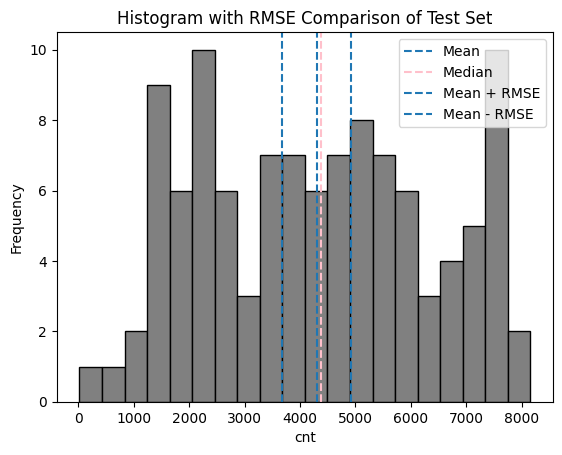

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Histogram
plt.hist(test_set_output, bins=20, color='gray', edgecolor='black')

# Compute stats
mean_val = np.mean(test_set_output)
median_val = np.median(test_set_output)
print(mean_val)
print(median_val)

# Add lines
plt.axvline(mean_val, linestyle='--', label='Mean')

plt.axvline(median_val, linestyle='--', label='Median', color='pink')

plt.axvline(mean_val + poly_rmse2, linestyle='--', label='Mean + RMSE')
plt.axvline(mean_val - poly_rmse2, linestyle='--', label='Mean - RMSE')

# Labels
plt.xlabel('cnt')
plt.ylabel('Frequency')
plt.title('Histogram with RMSE Comparison of Test Set')

plt.legend()
plt.show()

The scale of the RMSE is being compared to the scale of the histogram. As shown the RMSE is about the mean on both sides and is small compared to the entire range. So, new predictions will stay within the range of possible values and the tested predictions had a high ratio of correct repsonses. There could still be room for improvement in the power of the model. As seen the the mean is skewed from the median and is being pulled by the higher density of lower values to the left. Could be some influence from this skew, the distribution of the cnt, and more model fine tuning to make this model more powerful. There can also be checks for more methods or refinement till there is irreducible error. The model during cross validation had a stable score as well so including the good prediction power it can be reliable.

## Phase 6 (Optional for Undergraduates) SVM Model
Train a SVM regressor with the `SVR` class from `sklearn`. Choose model setting carefully so that the model's performance is optimized. Compare the performance of the SVM model with the polynomial model.

In [ ]:
#initializing model
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

In [ ]:
# Grid search

param_grid = {
    'C': [0.1, 1, 10, 50],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['rbf','linear'],
    'gamma': [0.001, 0.01, 0.1, 1]
}
grid_search = GridSearchCV(estimator=SVR(),
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error')
grid_search.fit(train_set_input, train_set_output)

print(f"Best score: {-grid_search.best_score_}")
print(f"Best parameters: {grid_search.best_params_}")

KeyboardInterrupt: 

In [ ]:
# Cross validation
SVR_model = SVR(kernel='linear', C=50, epsilon=0.1)
SVR_model.fit(train_set_input, train_set_output)


SVR_scores = cross_val_score(SVR_model, train_set_input, train_set_output, cv=5)
print(SVR_scores)
print(SVR_scores.mean())

[0.80119918 0.78091186 0.76290559 0.76659661 0.8422705 ]
0.7907767466083289


In [ ]:
#RMSE on test set
SVR_predictions = SVR_model.predict(test_set_input)

SVR_mse = mean_squared_error(test_set_output, SVR_predictions)
SVR_rmse = np.sqrt(SVR_mse)

print(SVR_rmse)

869.207298834806


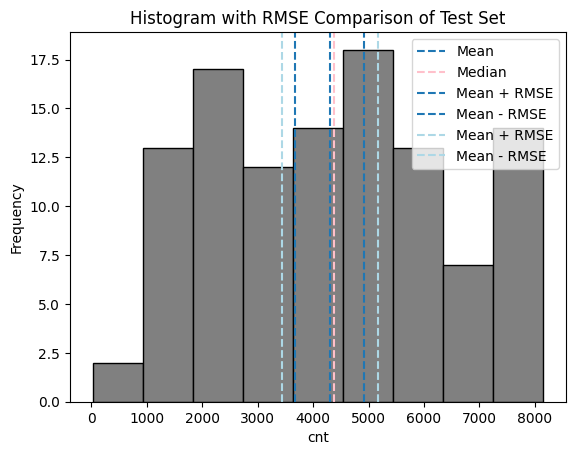

In [ ]:
# Histogram
plt.hist(test_set_output, bins=9, color='gray', edgecolor='black')

# Compute stats
mean_val = np.mean(test_set_output)
median_val = np.median(test_set_output)

# Add lines
plt.axvline(mean_val, linestyle='--', label='Mean')

plt.axvline(median_val, linestyle='--', label='Median', color='pink')

plt.axvline(mean_val + poly_rmse2, linestyle='--', label='Mean + RMSE')
plt.axvline(mean_val - poly_rmse2, linestyle='--', label='Mean - RMSE')

plt.axvline(mean_val + SVR_rmse, linestyle='--', label='Mean + RMSE',color='lightblue')
plt.axvline(mean_val - SVR_rmse, linestyle='--', label='Mean - RMSE',color='lightblue')

# Labels
plt.xlabel('cnt')
plt.ylabel('Frequency')
plt.title('Histogram with RMSE Comparison of Test Set')

plt.legend()
plt.show()

As shown the RMSE of the SVR is larger than the polynomial. This means the polynomial 3rd degree model has a higher power than the SVR model. The variation of the SVR model in cross validation is also slightly higher than the polynomial. So, the polynomial model is slightly more reliable and has more power to predict correctly than the SVR model. The SVR models score is about the same as the base linear model. A linear regression doesn't seem to be the best model to predict on this data. Next I would do is better optimize the parameters of the SVR because it is shown a degree 3 polynomial performed better across multiple folds. There would need to be more analysis into why the linear model had less power compared to the polynomial. There could be some relationships not accounted for by linear or linear assumptions were violated?